In [1]:
from pcntoolkit.dataio.norm_data import NormData
from pcntoolkit.normative_model import NormativeModel
import pandas as pd
import importlib
import pcntoolkit
importlib.reload(pcntoolkit)
from pcntoolkit.math_functions.thrive import get_correlation_matrix
import matplotlib.pyplot as plt

model = NormativeModel.load("save_dir_SC_all_regions")
#model = model[:, 'Left-Lateral-Ventricle']
test = pd.read_pickle("/Users/johannabayer/Documents/DATA/SC/test_SC_demented_adults_ADNI.pkl")


covariates = ["age"]
batch_effects = ["sex", "site_id2"]

features_to_model = [
    'Left-Lateral-Ventricle',
]

# features_to_model = [
#  'L_bankssts',
#  'L_caudalanteriorcingulate',
#  'L_caudalmiddlefrontal',
#  'L_cuneus',
#  'L_entorhinal',
#  'L_fusiform',
#  'L_inferiorparietal',
#  'L_inferiortemporal',
#  'L_isthmuscingulate',
#  'L_lateraloccipital',
#  'L_lateralorbitofrontal',
#  'L_lingual',
#  'L_medialorbitofrontal',
#  'L_middletemporal',
#  'L_parahippocampal',
#  'L_paracentral',
#  'L_parsopercularis',
#  'L_parsorbitalis',
#  'L_parstriangularis',
#  'L_pericalcarine',
#  'L_postcentral',
#  'L_posteriorcingulate',
#  'L_precentral',
#  'L_precuneus',
#  'L_rostralanteriorcingulate',
#  'L_rostralmiddlefrontal',
#  'L_superiorfrontal',
#  'L_superiorparietal',
#  'L_superiortemporal',
#  'L_supramarginal',
#  'L_frontalpole',
#  'L_temporalpole',
#  'L_transversetemporal',
#  'L_insula',
#  'R_bankssts',
#  'R_caudalanteriorcingulate',
#  'R_caudalmiddlefrontal',
#  'R_cuneus',
#  'R_entorhinal',
#  'R_fusiform',
#  'R_inferiorparietal',
#  'R_inferiortemporal',
#  'R_isthmuscingulate',
#  'R_lateraloccipital',
#  'R_lateralorbitofrontal',
#  'R_lingual',
#  'R_medialorbitofrontal',
#  'R_middletemporal',
#  'R_parahippocampal',
#  'R_paracentral',
#  'R_parsopercularis',
#  'R_parsorbitalis',
#  'R_parstriangularis',
#  'R_pericalcarine',
#  'R_postcentral',
#  'R_posteriorcingulate',
#  'R_precentral',
#  'R_precuneus',
#  'R_rostralanteriorcingulate',
#  'R_rostralmiddlefrontal',
#  'R_superiorfrontal',
#  'R_superiorparietal',
#  'R_superiortemporal',
#  'R_supramarginal',
#  'R_frontalpole',
#  'R_temporalpole',
#  'R_transversetemporal',
#  'R_insula'
# ]

norm_test = NormData.from_dataframe(
    name="test", dataframe=test, covariates=covariates, batch_effects=batch_effects, response_vars=features_to_model
)

norm_test = norm_test.sel(response_vars=["Left-Lateral-Ventricle"])

path = "/Users/johannabayer/Documents/Github/PCNtoolkit/pcntoolkit/save_dir_Sc_all_regions/results/Velocity"
# get correlation matrix
#get_correlation_matrix(norm_test, bandwidth=3, covariate_name="age", matrix_path=path )

model.compute_correlation_matrix(norm_test, bandwidth=5, covariate="age", matrix_path=path)


import numpy as np
import pandas as pd
import xarray as xr
from pcntoolkit import NormData

# Extract structure from existing NormData
response_vars = norm_test.response_vars.to_numpy()
batch_effect_names = norm_test.batch_effects.coords["batch_effect_dims"].to_numpy().tolist()
n_rv = len(response_vars)

# Define grid axes
ages = np.arange(0, 100, 1)
z_scores = np.arange(-4, 4.0, 1)

# All age × Z combinations
age_grid, z_grid = np.meshgrid(ages, z_scores)
age_flat = age_grid.flatten()
z_flat = z_grid.flatten()
n = len(age_flat)

# Build dataframe
df_dict = {
    "age": age_flat,
    "subjects": np.arange(n),
}

# Add one reference value per batch effect from first observation
ref_batch_values = norm_test.batch_effects.isel(observations=0).to_numpy()

for be_name, be_val in zip(batch_effect_names, ref_batch_values):
    df_dict[be_name] = np.full(n, be_val)

# Add dummy response columns
for rv in response_vars:
    df_dict[rv] = np.zeros(n)

df_grid = pd.DataFrame(df_dict)

grid_data = NormData.from_dataframe(
    name="grid",
    dataframe=df_grid,
    covariates=["age"],
    batch_effects=batch_effect_names,
    response_vars=response_vars.tolist(),
    subject_ids="subjects",
)

# Same Z for all response vars at each row
Z = np.tile(z_flat[:, None], (1, n_rv))

grid_data["Z"] = xr.DataArray(
    Z,
    dims=("observations", "response_vars"),
    coords={
        "observations": grid_data.coords["observations"],
        "response_vars": response_vars,
    },
)
print(norm_test.batch_effects)
print(type(norm_test.batch_effects.values[0]))
print(batch_effects)




Process: 54159 - 2026-04-15 12:19:40 - Dataset "test" created.
    - 50468 observations
    - 50468 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (2)
	site_id2 (125)
    
Process: 54159 - 2026-04-15 12:19:40 - Dataset "grid" created.
    - 800 observations
    - 800 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
<xarray.DataArray 'batch_effects' (observations: 50468, batch_effect_dims: 2)> Size: 13MB
array([['1.0', '1.0'],
       ['1.0', '1.0'],
       ['0.0', '1.0'],
       ...,
       ['0.0', '116.0'],
       ['0.0', '116.0'],
       ['0.0', '116.0']], shape=(50468, 2), dtype='<U32')
Coordinates:
  * observations       (observations) int64 404kB 0 1 2 3 ... 50465 50466 50467
  * batch_effect_dims  (batch_effect_dims) <U8 64B 'sex' 'site_id2'
<class 'numpy.ndarray'>
['sex', 'site_id2']


In [2]:
model.compute_thrivelines(norm_test, span=3, covariate="age", z_thrive=1.96,grid_data=grid_data, matrix_path=path)

Sampling: []
Sampling: []


<xarray.NormData> Size: 15MB
Dimensions:            (observations: 50468, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, offset: 2, dummy_obs: 800)
Coordinates:
  * observations       (observations) int64 404kB 0 1 2 3 ... 50465 50466 50467
  * response_vars      (response_vars) <U22 88B 'Left-Lateral-Ventricle'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U8 64B 'sex' 'site_id2'
  * offset             (offset) int64 16B 0 3
  * dummy_obs          (dummy_obs) int64 6kB 0 1 2 3 4 5 ... 795 796 797 798 799
Data variables:
    subject_ids        (observations) int64 404kB 0 1 2 3 ... 50465 50466 50467
    Y                  (observations, response_vars) float64 404kB -0.3521 .....
    X                  (observations, covariates) float64 404kB -1.101 ... 1.04
    batch_effects      (observations, batch_effect_dims) <U32 13MB '1.0' ... ...
    thrive_Z           (dummy_obs, response_vars, offset) float64 13kB -4.0 ....
    thrive_Y           (dummy_obs, response_vars, offset) float64 13kB -1.42 ...
    thrive_X           (dummy_obs, offset) float64 13kB -2.193 -2.062 ... 2.264
Attributes:
    real_ids:                       False
    is_scaled:                      True
    name:                           test
    unique_batch_effects:           {np.str_('sex'): [np.str_('0.0'), np.str_...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(37.3...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('0.0'): {np.str...
    thrive_covariate:               age
    z_thrive:                       1.96

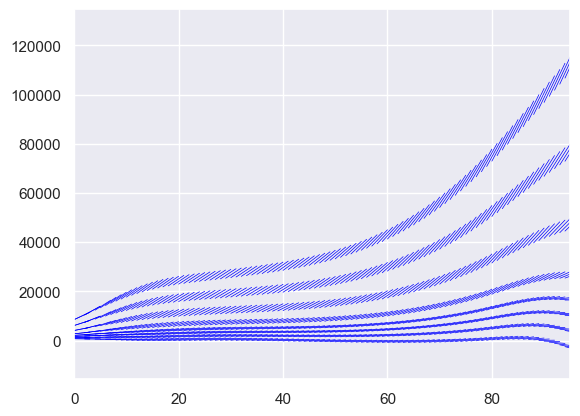

<xarray.DataArray 'thrive_Y' (dummy_obs: 800, response_vars: 1, offset: 2)> Size: 13kB
array([[[   754.1870979 ,    669.42751004]],

       [[   754.1870979 ,    669.42751004]],

       [[   698.60062202,    644.57265684]],

       ...,

       [[114104.37803512, 127878.65286403]],

       [[116587.84704503,  80460.02534328]],

       [[119090.60998273,  81548.42044444]]], shape=(800, 1, 2))
Coordinates:
  * dummy_obs      (dummy_obs) int64 6kB 0 1 2 3 4 5 ... 794 795 796 797 798 799
  * response_vars  (response_vars) <U22 88B 'Left-Lateral-Ventricle'
  * offset         (offset) int64 16B 0 3

In [3]:
from pcntoolkit.util.plotter import plot_centiles, plot_centiles_advanced
import matplotlib.pyplot as plt
thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]


import matplotlib.pyplot as plt
import numpy as np

thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]
thrive_Y = norm_test["thrive_Y"]

thrive_X_raw = model.inscalers["age"].inverse_transform(thrive_X)
thrive_Y_raw = model.outscalers["Left-Lateral-Ventricle"].inverse_transform(thrive_Y)   


for x, z in zip(thrive_X_raw, thrive_Y_raw):
    plt.plot(np.ravel(x), np.ravel(z), color = "blue", linewidth=0.5)

plt.xlim(0, 95) 
plt.show()
thrive_Y_raw



In [4]:
import copy

def subset_model(model, response_vars):
    sub = copy.deepcopy(model)
    sub.response_vars = [rv for rv in response_vars if rv in model.response_vars]
    sub.regression_models = {rv: sub.regression_models[rv] for rv in sub.response_vars}
    sub.outscalers = {rv: sub.outscalers[rv] for rv in sub.response_vars}
    return sub

small_model = subset_model(model, ["Left-Lateral-Ventricle"])
small_model

Sampling: []


Process: 92999 - 2026-04-14 15:38:29 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 92999 - 2026-04-14 15:38:29 - Computing centiles for 1 response variables.
Process: 92999 - 2026-04-14 15:38:29 - Computing centiles for Left-Lateral-Ventricle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []


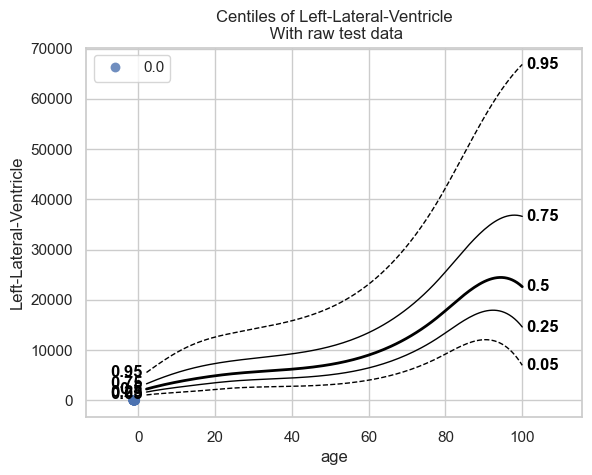

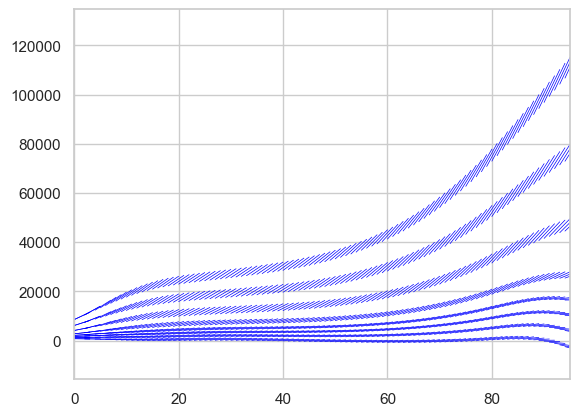

<xarray.DataArray 'thrive_Y' (dummy_obs: 800, response_vars: 1, offset: 2)> Size: 13kB
array([[[   754.1870979 ,    669.42751004]],

       [[   754.1870979 ,    669.42751004]],

       [[   698.60062202,    644.57265684]],

       ...,

       [[114104.37803512, 127878.65286403]],

       [[116587.84704503,  80460.02534328]],

       [[119090.60998273,  81548.42044444]]], shape=(800, 1, 2))
Coordinates:
  * dummy_obs      (dummy_obs) int64 6kB 0 1 2 3 4 5 ... 794 795 796 797 798 799
  * response_vars  (response_vars) <U22 88B 'Left-Lateral-Ventricle'
  * offset         (offset) int64 16B 0 3

In [12]:
import matplotlib.pyplot as plt
thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]


import matplotlib.pyplot as plt
import numpy as np

thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]
thrive_Y = norm_test["thrive_Y"]

thrive_X_raw = small_model.inscalers["age"].inverse_transform(thrive_X)
thrive_Y_raw = small_model.outscalers["Left-Lateral-Ventricle"].inverse_transform(thrive_Y)   



plot_centiles_advanced(
    model=small_model,
    response_vars=["Left-Lateral-Ventricle"],
    scatter_data=norm_test,        # filtered to known sites
    harmonize_data=False,
)

for x, z in zip(thrive_X_raw, thrive_Y_raw):
    plt.plot(np.ravel(x), np.ravel(z), color = "blue", linewidth=0.5)

plt.xlim(0, 95) 
plt.show()
thrive_Y_raw



In [7]:
print("cormat size:", small_model.correlation_matrix.shape)
print("covariate_ranges:", small_model.covariate_ranges["age"])


cormat size: (1, 99, 99)
covariate_ranges: {'min': 2.091666666666667, 'max': 100.0}


In [6]:
known_sites = list(small_model.unique_batch_effects["site_id2"])
mask = norm_test.batch_effects.sel(batch_effect_dims="site_id2").isin(known_sites)
norm_test_known = norm_test.sel(observations=norm_test.observations[mask.values])

from pcntoolkit.util.plotter import plot_centiles_advanced

plot_centiles_advanced(
    model=small_model,
    response_vars=["Left-Lateral-Ventricle"],
    scatter_data=norm_test_known,        # filtered to known sites
    batch_effects={"site_id2": ["2.0"]}, # reference site for centiles AND thrivelines
    show_thrivelines=True,
    z_thrive=1.96,                        # Z-score to thrive towards (0 = mean)
)


Sampling: []


Process: 92999 - 2026-04-13 15:29:37 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 92999 - 2026-04-13 15:29:37 - Computing centiles for 1 response variables.
Process: 92999 - 2026-04-13 15:29:37 - Computing centiles for Left-Lateral-Ventricle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


Process: 92999 - 2026-04-13 15:29:47 - Making predictions on 1 response variables.
Process: 92999 - 2026-04-13 15:29:47 - Computing z-scores for 1 response variables.
Process: 92999 - 2026-04-13 15:29:47 - Computing z-scores for Left-Lateral-Ventricle.


Sampling: []


...

Process: 92999 - 2026-04-13 15:30:02 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 92999 - 2026-04-13 15:30:02 - Computing centiles for 1 response variables.
Process: 92999 - 2026-04-13 15:30:02 - Computing centiles for Left-Lateral-Ventricle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


Process: 92999 - 2026-04-13 15:30:13 - Harmonizing data on 1 response variables.
Process: 92999 - 2026-04-13 15:30:13 - Harmonizing data for Left-Lateral-Ventricle.


Sampling: []


IndexError: index 116 is out of bounds for axis 0 with size 103

Sampling: []


Process: 54159 - 2026-04-15 12:20:33 - Dataset "grid" created.
    - 1050 observations
    - 1050 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	site_id2 (1)
	sex (1)
    
Process: 54159 - 2026-04-15 12:20:33 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    


Sampling: []
Sampling: []


Process: 54159 - 2026-04-15 12:20:58 - Computing centiles for 1 response variables.
Process: 54159 - 2026-04-15 12:20:58 - Computing centiles for Left-Lateral-Ventricle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []


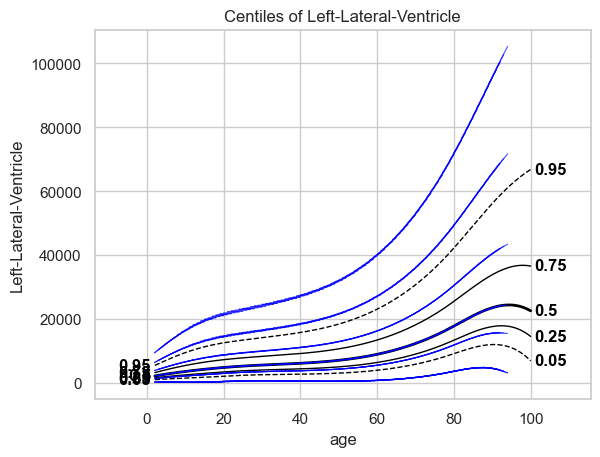

In [5]:
# Prepare grid_data: ages across lifespan, Z set to your anchor values
import xarray as xr
import numpy as np
from pcntoolkit.util.plotter import plot_centiles_advanced

ages = np.linspace(model.covariate_ranges["age"]["min"], 
                   model.covariate_ranges["age"]["max"] - model.correlation_matrix.shape[1]//10, 
                   150)

# Create one row per anchor Z per age — here 9 Z anchors × 150 ages
z_anchors = [-3, -3, -1, 0, 1, 2, 3]
rows = []
for z in z_anchors:
    for age in ages:
        rows.append({"age": age, "site_id2": "2.0", "sex": "1.0","Left-Lateral-Ventricle": 0})
grid_df = pd.DataFrame(rows)
grid_data = NormData.from_dataframe("grid", grid_df, covariates=["age"], 
                                     response_vars=["Left-Lateral-Ventricle"],
                                     batch_effects=["site_id2", "sex"])
# Set Z scores to anchor values
grid_data["Z"] = xr.DataArray(
    np.repeat(z_anchors, len(ages)).reshape(-1, 1),
    dims=("observations", "response_vars"),
    coords={"observations": grid_data.observations, "response_vars": ["Left-Lateral-Ventricle"]}
)

plot_centiles_advanced(
    model=small_model,
    response_vars=["Left-Lateral-Ventricle"],
    grid_data=grid_data,
    #batch_effects={"site_id2": ["1.0"], "sex": ["1.0"]},
    harmonize_data=True,
)



In [11]:
model.outscalers

{'L_inferiortemporal': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163bde810>,
 'L_temporalpole': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163c44200>,
 'L_postcentral': <pcntoolkit.math_functions.scaler.StandardScaler at 0x164c11550>,
 'R_isthmuscingulate': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163bdd280>,
 'L_superiortemporal': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163c20080>,
 'R_parsopercularis': <pcntoolkit.math_functions.scaler.StandardScaler at 0x1632fed20>,
 'R_cuneus': <pcntoolkit.math_functions.scaler.StandardScaler at 0x1632fe990>,
 'R_caudalanteriorcingulate': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163bdf440>,
 'L_precentral': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163bcc350>,
 'L_inferiorparietal': <pcntoolkit.math_functions.scaler.StandardScaler at 0x16542dfa0>,
 'R_parstriangularis': <pcntoolkit.math_functions.scaler.StandardScaler at 0x16579ec30>,
 'L_posteriorcingulate': <pcntoolkit.mat

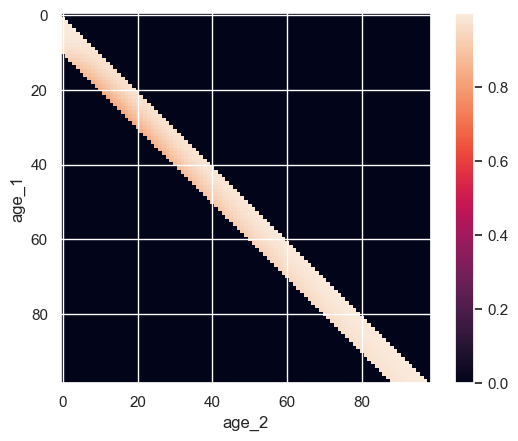

In [16]:
cormat = model.correlation_matrix

import matplotlib.pyplot as plt
plt.imshow(cormat.sel(response_vars="Left-Lateral-Ventricle").values)
plt.colorbar()
plt.xlabel("age_2")
plt.ylabel("age_1")
plt.show()
